In [42]:
import pandas as pd
import numpy as np

FamaFrench_df = pd.read_csv('./Fama French Factors.csv', low_memory=False)
CRSP_Universe_df = pd.read_csv('./CRSP Mutual Fund Universe.csv', low_memory=False)
CRSP_Returns_df = pd.read_csv('./CRSP Mutual Fund Returns.csv', low_memory=False)

print(f"Original: {CRSP_Universe_df.shape}")

Original: (156152, 73)


In [43]:
#1 CRSP objective code is in the {EDCM, EDCS, EDYG, EDYB, EDYI} set
CRSP_Universe_df = CRSP_Universe_df[CRSP_Universe_df['crsp_obj_cd'].isin(['EDCM', 'EDCS', 'EDYG', 'EDYB', 'EDYI'])]
print(f"After obj_cd filter: {CRSP_Universe_df.shape}")

After obj_cd filter: (55785, 73)


In [44]:
# remove target date funds
tdf_flag = (CRSP_Universe_df['lipper_class_name'].str.contains('Target') | 
            CRSP_Universe_df['lipper_class_name'].str.contains('Trgt'))
not_tdf_flag = np.logical_not(tdf_flag)
CRSP_Universe_df = CRSP_Universe_df[not_tdf_flag]
print(f"After target date fund removal: {CRSP_Universe_df.shape}")

After target date fund removal: (40335, 73)


In [45]:
# screening for additional criteria
CRSP_Universe_df = CRSP_Universe_df[
    (CRSP_Universe_df['caldt'] == '2023-12-29') &
    (CRSP_Universe_df['sales_restrict'] == 'N') &
    (CRSP_Universe_df['retail_fund'] == 'Y') &
    (CRSP_Universe_df['dead_flag'] == 'N') &
    (CRSP_Universe_df['index_fund_flag'].isna()) &
    (CRSP_Universe_df['et_flag'].isna())
]
print(f"After additional criteria: {CRSP_Universe_df.shape}")

After additional criteria: (2296, 73)


In [46]:
# extracting largest fund from each fund family
fam_aum_max = CRSP_Universe_df.groupby(['crsp_portno']).agg({'tna_latest': 'max'})
fam_aum_max.columns = ['tna_max']
fam_aum_max = fam_aum_max.reset_index()
CRSP_Universe_df = CRSP_Universe_df.merge(fam_aum_max, on='crsp_portno', how='inner')
CRSP_Universe_df = CRSP_Universe_df.loc[(CRSP_Universe_df['tna_latest']==CRSP_Universe_df['tna_max'])]
print(f"Final shape (should be 1298 rows): {CRSP_Universe_df.shape}")

Final shape (should be 1298 rows): (1298, 74)


In [47]:
# double checking existence of 1 common firm identifier between both dataframes
matching = set(CRSP_Universe_df.columns) & set(CRSP_Returns_df.columns)
print(matching)

{'crsp_fundno', 'caldt'}


In [48]:
# inner-joining on crsp_fundno (not date)
manager_returns_df = CRSP_Returns_df.merge(CRSP_Universe_df, on='crsp_fundno', how='inner')

# error checking
# manager_returns_df.head
# print(manager_returns_df['mret'].isnull().sum(), manager_returns_df['mret'].dtype)
# print(manager_returns_df.groupby('crsp_fundno').size().value_counts())

# keeping 1 date column
manager_returns_df = manager_returns_df.drop(columns=['caldt_y'])
manager_returns_df = manager_returns_df.rename(columns={'caldt_x':'caldt'})

In [49]:
# professor's helper function
def annualized_geometric_return(returns):
    cumulative_return = np.prod(1 + returns) - 1
    num_years = len(returns)
    annret = (1 + cumulative_return) ** (12 / num_years) - 1
    return annret

In [50]:
# ensure mret are numbers
manager_returns_df['mret'] = pd.to_numeric(manager_returns_df['mret'], errors='coerce')

print(manager_returns_df['mret'].dtype)
print(manager_returns_df['mret'].isnull().sum())
print(manager_returns_df['mret'].head())

float64
131
0    0.097378
1    0.048635
2   -0.002441
3    0.039152
4   -0.045526
Name: mret, dtype: float64


In [51]:
# filter managers with 69 months of history
filtered = manager_returns_df.groupby('crsp_fundno').filter(
    lambda x: (len(x) == 69) and x['mret'].notnull().all()
)

# annualized geometric returns for each manager
annualized_returns = filtered.groupby('crsp_fundno')['mret'].apply(annualized_geometric_return)
annualized_df = annualized_returns.reset_index()
annualized_df.columns = ['crsp_fundno' , 'annualized_return']

# assign decile to each manager based on annualized return
annualized_df['decile'] = pd.qcut(annualized_df['annualized_return'], 10, labels=False)

# map decile back to filtered df monthly data
filtered = filtered.merge(
    annualized_df[['crsp_fundno', 'decile']],
    on='crsp_fundno', how='left'
)

# avg decile returns
decile_avg_mret = filtered.groupby('decile')['mret'].mean().sort_index()
print(decile_avg_mret)

decile
0    0.008335
1    0.010273
2    0.010995
3    0.011366
4    0.012025
5    0.012510
6    0.013286
7    0.014104
8    0.015126
9    0.016915
Name: mret, dtype: float64


In [52]:
# merge caused caldt to be dropped and generated caldt_x
# will rename caldt_x to caldt
filtered = filtered.rename(columns={'caldt_x': 'caldt'})

# merging fama french factors model
FamaFrench_df.rename(columns= {FamaFrench_df.columns[0]: 'ff_date'}, inplace=True)
FamaFrench_df['ff_date'] = FamaFrench_df['ff_date'].astype(int)

# adding a column compatible with fff model's YYYYMM format to 'filtered' df
filtered['ff_date'] = pd.to_datetime(filtered['caldt']).dt.strftime('%Y%m').astype(int)

# merge
merged = filtered.merge(FamaFrench_df, on='ff_date', how='inner')

In [53]:
# excess decile return
merged['excess_return'] = merged['mret'] - merged['RF']

# to get equally weighted decile series
decile_ts = merged.groupby(['decile', 'caldt'])['excess_return'].mean().reset_index()

In [54]:
import statsmodels.api as sm

# CAPM regression
capm_results = {}

for d in decile_ts['decile'].unique():
    # extract time series for this decile
    sub = merged[merged['decile'] == d].copy().reset_index(drop=True)
    X = sub[['Mkt-RF']]
    y = sub['excess_return']
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    capm_results[d] = model

In [55]:
# Five-Factor regression

five_factor_results = {}

for d in decile_ts['decile'].unique():
    # extract time series for this decile
    sub = merged[merged['decile'] == d].copy()
    # predictors: Mkt-RF, SMB, HML, RMW, MOM
    X_ff5 = sub[['Mkt-RF', 'SMB', 'HML', 'RMW', 'MOM']]
    y = sub['excess_return']
    X_ff5 = sm.add_constant(X_ff5)
    model_ff5 = sm.OLS(y, X_ff5).fit()
    five_factor_results[d] = model_ff5

<Figure size 1000x600 with 0 Axes>

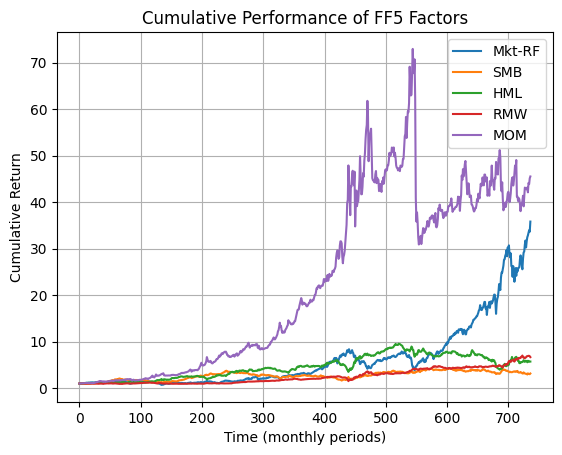

In [56]:
import matplotlib.pyplot as plt

# 1. Plot the cumulative performance over the period of analysis for the FF5 factors.
ff5_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'MOM']
ff5_cum = (FamaFrench_df[ff5_cols] +1).cumprod()

plt.figure(figsize=(10,6))
ff5_cum.plot()
plt.title("Cumulative Performance of FF5 Factors")
plt.xlabel("Time (monthly periods)")
plt.ylabel("Cumulative Return")
plt.legend(ff5_cols)
plt.grid()
plt.show()

In [57]:
print(
"1) Cumulative performance of FF5 factors\n\n"
"Based on my plot, momentum (MOM) dominates long-run cumulative returns, "
"the market factor (Mkt-RF) trends upward strongly, especially in the most recent stretch, "
"while value (HML) and size (SMB) are comparatively flat to down, and quality (RMW) drifts modestly up.\n\n"
"a) Last 69 months vs. long run.\n"
"Based on the plot, I believe the past ~69 months are broadly consistent with the long-run ranking: "
"Mkt-RF strong, MOM volatile but net\npositive, HML weak/negative, SMB soft, and RMW mildly positive. "
"If anything, the recent HML underperformance looks a bit more pronounced\nthan its long-run average.\n\n"
"b) Strategies likely to do well/poorly.\n"
"From these factor returns, I gather that:\n\n"
"Strategies that likely performed well: portfolios with high market exposure (Mkt-RF) and strong momentum (MOM) tilts, "
"with some additional\nsupport from profitable, high-quality firms (RMW).\n\n"
"Strategies that likely performed poorly: portfolios tilted toward value stocks (high HML) and small-cap stocks (high SMB) over this period."
)

1) Cumulative performance of FF5 factors

Based on my plot, momentum (MOM) dominates long-run cumulative returns, the market factor (Mkt-RF) trends upward strongly, especially in the most recent stretch, while value (HML) and size (SMB) are comparatively flat to down, and quality (RMW) drifts modestly up.

a) Last 69 months vs. long run.
Based on the plot, I believe the past ~69 months are broadly consistent with the long-run ranking: Mkt-RF strong, MOM volatile but net
positive, HML weak/negative, SMB soft, and RMW mildly positive. If anything, the recent HML underperformance looks a bit more pronounced
than its long-run average.

b) Strategies likely to do well/poorly.
From these factor returns, I gather that:

Strategies that likely performed well: portfolios with high market exposure (Mkt-RF) and strong momentum (MOM) tilts, with some additional
support from profitable, high-quality firms (RMW).

Strategies that likely performed poorly: portfolios tilted toward value stocks (high H

In [58]:
# 2. Create two tables showing the coefficients (including the intercept term), t-stats, and R2 for the CAPM and FF5 regressions.

# create helper function to extract summary stats from 'capm_results' and 'five_factor_results'
def extract_stats(results_dict, factors):
    rows = []
    for d, result in results_dict.items():
        params = result.params
        tstats = result.tvalues
        r2 = result.rsquared
        row = {'decile': d, 'R2': r2}
        row.update({f'{f}_coef': params.get(f, None) for f in ['const'] + factors})
        row.update({f'{f}_tstat': tstats.get(f, None) for f in ['const'] + factors})
        rows.append(row)
    return pd.DataFrame(rows).sort_values('decile')

# CAPM table
capm_table = extract_stats(capm_results, ['Mkt-RF'])
print("CAPM Regression Table")
print(capm_table)

# FF5 table
ff5_table = extract_stats(five_factor_results, ['Mkt-RF', 'SMB', 'HML', 'RMW', 'MOM'])
print("\nFF5 Regression Table")
print(ff5_table)

CAPM Regression Table
   decile        R2  const_coef  Mkt-RF_coef  const_tstat  Mkt-RF_tstat
0       0  0.713733   -0.005597     0.960461   -15.429171    142.460401
1       1  0.765374   -0.004673     1.041182   -13.535897    162.260309
2       2  0.768229   -0.003955     1.041404   -11.592491    164.258658
3       3  0.790488   -0.002926     0.989093    -9.594481    174.504783
4       4  0.793992   -0.002491     1.006903    -8.144542    177.124529
5       5  0.827984   -0.001796     0.990211    -6.645212    197.101501
6       6  0.841741   -0.001300     1.012527    -4.945467    207.189797
7       7  0.871902   -0.000392     1.005297    -1.705676    235.383103
8       8  0.856055    0.000502     1.015517     2.014472    219.086890
9       9  0.835309    0.001860     1.049774     6.692519    203.189533

FF5 Regression Table
   decile        R2  const_coef  Mkt-RF_coef  SMB_coef  HML_coef  RMW_coef  \
0       0  0.769394   -0.003794     0.887568  0.370092  0.115478 -0.009623   
1       

In [59]:
# 3. ﻿﻿﻿Characterize the performance of the best and worst performing managers from the perspective of the CAPM and FF5 models.
best_decile = capm_table['decile'].iloc[-1]
worst_decile = capm_table['decile'].iloc[0]

print("Performance characterization (CAPM):")
print("Best Decile:")
print(capm_table[capm_table['decile'] == best_decile])
print("\nWorst Decile:")
print(capm_table[capm_table['decile'] == worst_decile])

print("\n\nPerformance characterization (FF5):")
print("Best Decile:")
print(ff5_table[ff5_table['decile'] == best_decile])
print("\nWorst Decile:")
print(ff5_table[ff5_table['decile'] == worst_decile])

Performance characterization (CAPM):
Best Decile:
   decile        R2  const_coef  Mkt-RF_coef  const_tstat  Mkt-RF_tstat
9       9  0.835309     0.00186     1.049774     6.692519    203.189533

Worst Decile:
   decile        R2  const_coef  Mkt-RF_coef  const_tstat  Mkt-RF_tstat
0       0  0.713733   -0.005597     0.960461   -15.429171    142.460401


Performance characterization (FF5):
Best Decile:
   decile        R2  const_coef  Mkt-RF_coef  SMB_coef  HML_coef  RMW_coef  \
9       9  0.856439     0.00155     1.069276 -0.034198 -0.178503 -0.028616   

   MOM_coef  const_tstat  Mkt-RF_tstat  SMB_tstat  HML_tstat  RMW_tstat  \
9  0.010685     5.748796     189.94822   -2.95375 -26.920544  -2.248097   

   MOM_tstat  
9   1.435711  

Worst Decile:
   decile        R2  const_coef  Mkt-RF_coef  SMB_coef  HML_coef  RMW_coef  \
0       0  0.769394   -0.003794     0.887568  0.370092  0.115478 -0.009623   

   MOM_coef  const_tstat  Mkt-RF_tstat  SMB_tstat  HML_tstat  RMW_tstat  \
0  0.015346

In [39]:
print(
"(a) Differences in factor loadings across deciles?\n"
"Yes—quite clear. Based on the FF5 estimates, SMB and HML trend from positive in the worst deciles to negative in the best decile. "
"Market beta also rises with decile. RMW flips sign twice (-,+,-) but remains small, MOM are small and mostly insignificant (except for decile 5 index[4]) across the board.\n\n"
"(b) Factor-based or skill-based?\n"
"Given R² values around 0.71–0.84 for CAPM and roughly 0.77–0.86 for FF5, most return variation appears factor-driven. "
"That said, the\neconomically and statistically meaningful alphas for Decile 9 (positive) and Decile 0 (negative) persist even after controlling for FF5\nfactors. "
"Based on those t-stats, I gather that performance isn’t purely due to factor exposure, there seems to be consistent evidence that\n"
"the best managers (Decile 9) were able to select assets or adjust exposures at the right times to outperform, "
"while the worst managers\n(Decile 0) showed the opposite pattern, suggesting poor selection or mistimed exposures.\n\n"
"(c) Skill or luck (from intercepts)?\n"
"The magnitudes and t-stats make it unlikely that the results are entirely due to luck. "
"My read is that the best decile shows signs of skill (or exposure to factors not captured by FF5), while the worst decile might be reflecting negative skill. "
"We can’t fully rule out model\nmisspecification, but since the intercepts remain significant after FF5 adjustment, I lean toward interpreting the results as evidence of\nskill."
)

(a) Differences in factor loadings across deciles?
Yes—quite clear. Based on the FF5 estimates, SMB and HML trend from positive in the worst deciles to negative in the best decile. Market beta also rises with decile. RMW flips sign twice (-,+,-) but remains small, MOM are small and mostly insignificant (except for decile 5 index[4]) across the board.

(b) Factor-based or skill-based?
Given R² values around 0.71–0.84 for CAPM and roughly 0.77–0.86 for FF5, most return variation appears factor-driven. That said, the
economically and statistically meaningful alphas for Decile 9 (positive) and Decile 0 (negative) persist even after controlling for FF5
factors. Based on those t-stats, I gather that performance isn’t purely due to factor exposure, there seems to be consistent evidence that
the best managers (Decile 9) were able to select assets or adjust exposures at the right times to outperform, while the worst managers
(Decile 0) showed the opposite pattern, suggesting poor selection or m